# Experiment 3 - INT8 KV cache: precision axis

H3 asks whether storing the KV cache in INT8 shifts the paged-vs-contiguous crossover. The lever is memory. Three things to check, in order of how clean the signal is:

1. Memory ratio - INT8 vs FP16 cache bytes. Deterministic, should hold exactly.
2. OOM frontier - does the smaller cache let us run cells FP16 can't?
3. Quality - perplexity cost of the quantization, measured separately on real GPT-2 weights.

Two CSVs: `exp3_precision_sweep.csv` (memory/latency, study model) and `exp3_perplexity.csv` (quality, HF GPT-2). They are different models on purpose - the study model is randomly initialized, so it's fine for memory but meaningless for perplexity. Decode here is launch-bound, so timing is read with care; memory and quality are the trustworthy axes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_results_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / 'experiments' / 'results'
        if cand.exists():
            return cand
    raise FileNotFoundError('experiments/results not found from ' + str(Path.cwd()))

RESULTS = find_results_dir()
df = pd.read_csv(RESULTS / 'exp3_precision_sweep.csv')

NUM = ['ttft_ms', 'tpot_ms', 'throughput', 'throughput_cv',
       'peak_memory_mb', 'cache_memory_mb', 'frag_ratio']
for c in NUM:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['ok'] = df['status'].str.lower().eq('ok')

fp16 = df[df.cache_type == 'paged_fp16']
int8 = df[df.cache_type == 'paged_int8']
print(f'{len(df)} rows | fp16 {len(fp16)} | int8 {len(int8)} | block_size {df.block_size.unique()}')
df.head()

40 rows | fp16 20 | int8 20 | block_size [16]


,cache_type,seq_len,batch,block_size,status,ttft_ms,tpot_ms,throughput,throughput_cv,peak_memory_mb,cache_memory_mb,frag_ratio,ok
0,paged_fp16,512,1,16,ok,7.454,7.035,137.1,18.29,171.88,9.0,0.0069,True
1,paged_fp16,512,8,16,ok,14.036,11.967,607.9,10.05,274.44,72.0,0.0069,True
2,paged_fp16,512,16,16,ok,15.164,10.635,1282.4,4.38,389.00,144.0,0.0069,True
3,paged_fp16,512,32,16,ok,29.317,10.738,2581.0,4.57,621.14,288.0,0.0069,True
4,paged_fp16,1024,1,16,ok,10.198,9.041,95.6,4.69,186.17,17.0,0.0037,True


## 1. Memory ratio

Same workload, same paging, only the storage precision differs. INT8 is one byte of data plus a per-token FP16 scale, so the expected ratio is `(1 + 2/head_dim)/2` = 0.516 at head_dim 64. If the cache accounting is right, the measured ratio is that number in every cell.

measured ratio: 0.5156 - 0.5159  (mean 0.5156)
expected (1 + 2/head_dim)/2 at head_dim 64: 0.5156


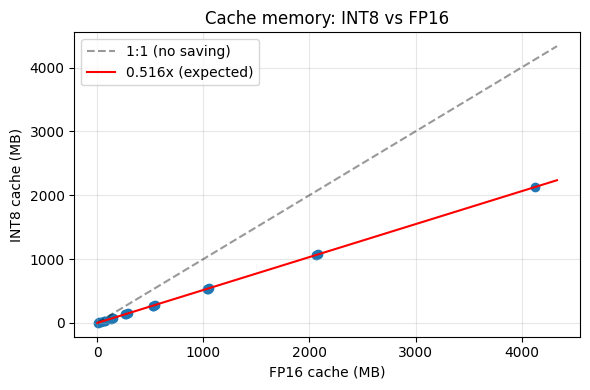

In [2]:
m = fp16.merge(int8, on=['seq_len', 'batch'], suffixes=('_fp16', '_int8'))
m['ratio'] = m['cache_memory_mb_int8'] / m['cache_memory_mb_fp16']
expected = (1 + 2/64) / 2
print(f'measured ratio: {m.ratio.min():.4f} - {m.ratio.max():.4f}  (mean {m.ratio.mean():.4f})')
print(f'expected (1 + 2/head_dim)/2 at head_dim 64: {expected:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(m.cache_memory_mb_fp16, m.cache_memory_mb_int8, color='#1f77b4')
lim = m.cache_memory_mb_fp16.max() * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='1:1 (no saving)')
ax.plot([0, lim], [0, lim * expected], 'r-', label=f'{expected:.3f}x (expected)')
ax.set(xlabel='FP16 cache (MB)', ylabel='INT8 cache (MB)', title='Cache memory: INT8 vs FP16')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. OOM frontier

If INT8 frees real headroom, it should survive `(seq_len, batch)` cells where FP16 runs out of memory. Compare the status grids.

In [3]:
def status_grid(sub):
    return sub.pivot(index='batch', columns='seq_len', values='status').sort_index()

print('FP16:'); print(status_grid(fp16)); print()
print('INT8:'); print(status_grid(int8)); print()

fail = lambda s: s.lower() in ('oom', 'slow')
fp16_fail = {(r.seq_len, r.batch) for r in fp16.itertuples() if fail(r.status)}
int8_fail = {(r.seq_len, r.batch) for r in int8.itertuples() if fail(r.status)}
rescued = fp16_fail - int8_fail
print(f'cells FP16 fails: {sorted(fp16_fail)}')
print(f'cells INT8 fails: {sorted(int8_fail)}')
print(f'cells INT8 rescues from FP16: {sorted(rescued) if rescued else "none"}')

FP16:
seq_len 512  1024 2048 4096 8192
batch                           
1         ok   ok   ok   ok   ok
8         ok   ok   ok   ok   ok
16        ok   ok   ok   ok   ok
32        ok   ok   ok   ok   ok

INT8:
seq_len 512  1024 2048 4096 8192
batch                           
1         ok   ok   ok   ok   ok
8         ok   ok   ok   ok   ok
16        ok   ok   ok   ok   ok
32        ok   ok   ok   ok   ok

cells FP16 fails: []
cells INT8 fails: []
cells INT8 rescues from FP16: none


## 3. Why the frontier doesn't move

The cache is a small slice of peak memory - the rest is prefill activations, which quantizing the cache does nothing for. Halving 10% of the budget can't move an OOM set by the other 90%.

In [4]:
okf = fp16[fp16.ok].copy()
okf['cache_share'] = okf['cache_memory_mb'] / okf['peak_memory_mb']
share = okf.pivot_table(index='batch', columns='seq_len', values='cache_share')
print('FP16 cache as fraction of peak memory:')
print((share * 100).round(1).astype(str) + '%')
print(f'\nmean cache share: {okf.cache_share.mean()*100:.1f}%  (max {okf.cache_share.max()*100:.1f}%)')

FP16 cache as fraction of peak memory:
seq_len   512    1024   2048   4096   8192
batch                                     
1         5.2%   9.1%  15.5%  24.1%  33.8%
8        26.2%  35.5%  44.1%  50.4%  54.3%
16       37.0%  44.9%  50.8%  54.6%  56.7%
32       46.4%  51.6%  55.0%  57.0%  58.0%

mean cache share: 40.5%  (max 58.0%)


## 4. Quality cost

Perplexity on WikiText-2 test, real GPT-2 weights, with the same per-token symmetric INT8 scheme applied to the KV cache. The claim is the delta, not the absolute PPL.

In [5]:
ppl = pd.read_csv(RESULTS / 'exp3_perplexity.csv')
print(ppl.to_string(index=False))
print(f'\nworst quality cost measured: +{ppl.ppl_pct_increase.max():.3f}% PPL, '
      f'top-1 agreement >= {ppl.top1_agreement.min():.3f}')

      model  ctx  n_tokens  ppl_fp16  ppl_int8  ppl_delta  ppl_pct_increase  top1_agreement
       gpt2  512    284614   35.9620   35.9627     0.0007             0.002          0.9854
gpt2-medium  512    284614   25.3947   25.3963     0.0016             0.006          0.9883

worst quality cost measured: +0.006% PPL, top-1 agreement >= 0.985


## 5. Latency - a caveat, not a finding

INT8 decode runs slower, but `INT8KVCache.read()` re-dequantizes the full history every step (invariant #5) and decode here is launch-bound. The tell that this is overhead, not arithmetic: the INT8/FP16 TPOT ratio does not climb with seq_len - it falls (from ~3x to ~1.3x). History-size dequant would make it grow; a fixed per-step cost instead shrinks as a fraction as FP16's own per-step cost rises with length. So it's extra per-step kernel launches, and a fused dequant-in-attention path would remove most of it. Don't report it as an intrinsic INT8 cost.

In [6]:
t = fp16[fp16.ok].merge(int8[int8.ok], on=['seq_len', 'batch'], suffixes=('_fp16', '_int8'))
t['tpot_ratio'] = t['tpot_ms_int8'] / t['tpot_ms_fp16']
by_seq = t.groupby('seq_len')['tpot_ratio'].mean()
print('INT8/FP16 TPOT ratio by seq_len (does not climb => fixed per-step overhead, not history dequant):')
print(by_seq.round(2).to_string())
print(f'\nrange {by_seq.min():.2f}x - {by_seq.max():.2f}x across a 16x span of seq_len')

INT8/FP16 TPOT ratio by seq_len (does not climb => fixed per-step overhead, not history dequant):
seq_len
512     1.77
1024    1.70
2048    1.77
4096    1.71
8192    1.48

range 1.48x - 1.77x across a 16x span of seq_len


## Verdict

In [7]:
print('=' * 60)
print(f'Memory:  INT8 cache = {m.ratio.mean():.3f}x FP16, exact across all cells.')
print(f'Quality: <= +{ppl.ppl_pct_increase.max():.3f}% PPL on WikiText-2 - effectively free.')
print(f'Frontier: INT8 rescues {len(rescued)} cells from FP16 OOM '
      f'(cache is only ~{okf.cache_share.mean()*100:.0f}% of peak).')
print(f'Latency: ~{by_seq.mean():.1f}x TPOT, does not climb with seq_len - launch overhead, caveat not finding.')
print('-' * 60)
h3_frontier = len(rescued) > 0
print(f'H3 (precision shifts the crossover): '
      f'{"SUPPORTED" if h3_frontier else "NOT SUPPORTED on this GPU"}.')
print('INT8 buys memory and costs almost nothing in quality, but on this hardware')
print('the cache is not the memory bottleneck, so the frontier does not move.')
print('Keep it a sub-result of the block-size study, not a co-headline.')
print('=' * 60)

Memory:  INT8 cache = 0.516x FP16, exact across all cells.
Quality: <= +0.006% PPL on WikiText-2 - effectively free.
Frontier: INT8 rescues 0 cells from FP16 OOM (cache is only ~41% of peak).
Latency: ~1.7x TPOT, does not climb with seq_len - launch overhead, caveat not finding.
------------------------------------------------------------
H3 (precision shifts the crossover): NOT SUPPORTED on this GPU.
INT8 buys memory and costs almost nothing in quality, but on this hardware
the cache is not the memory bottleneck, so the frontier does not move.
Keep it a sub-result of the block-size study, not a co-headline.
